In [15]:
import numpy as np
import matplotlib.pylab as plt
from ioMicro import * 

In [4]:
#D108 - day15 DKO
#D110 - day15 WT
#D118 - day0 WT

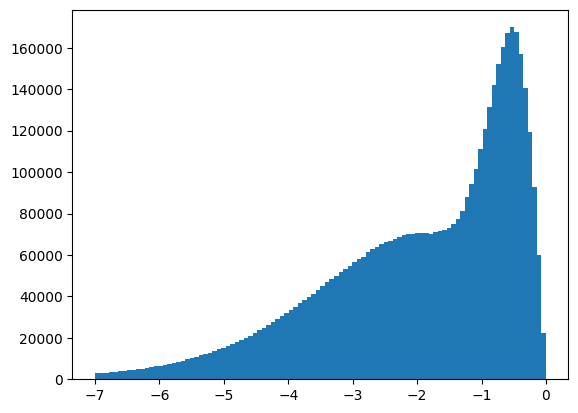

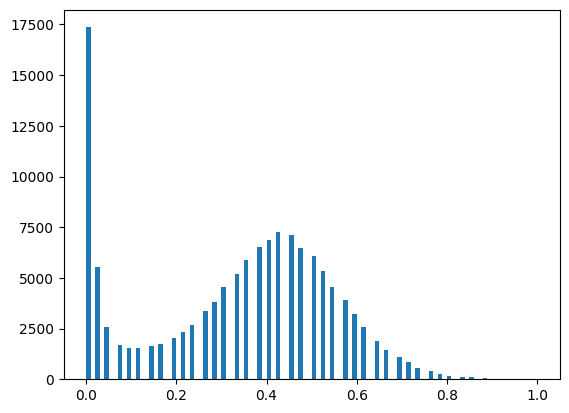

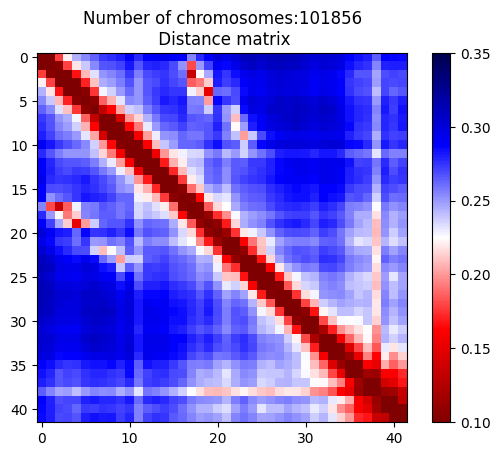

In [5]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D118_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-3]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.]=np.nan
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D118 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

In [6]:
zxys_fs[:,0,-4]

array([0.54334996, 0.18035353, 0.43212088, ..., 0.32977779, 0.04941407,
       0.00268486])

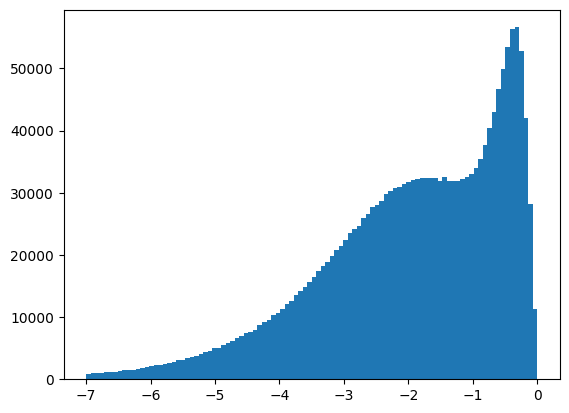

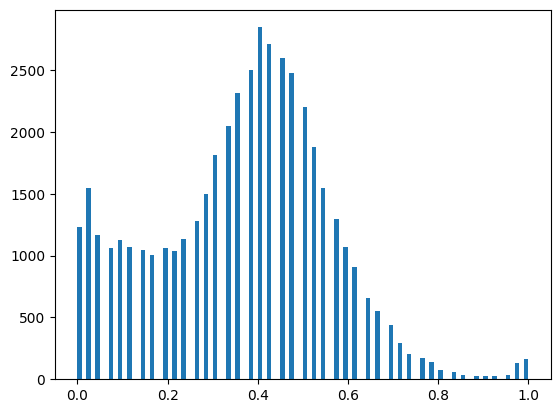

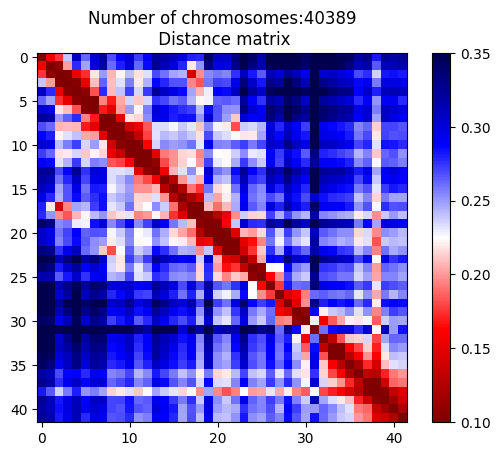

In [7]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D108_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-4]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.25]=np.nan
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D108 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

C:\Users\carlos\AppData\Local\Temp\ipykernel_20868\2095675555.py:26: RuntimeWarning: divide by zero encountered in log
  H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])


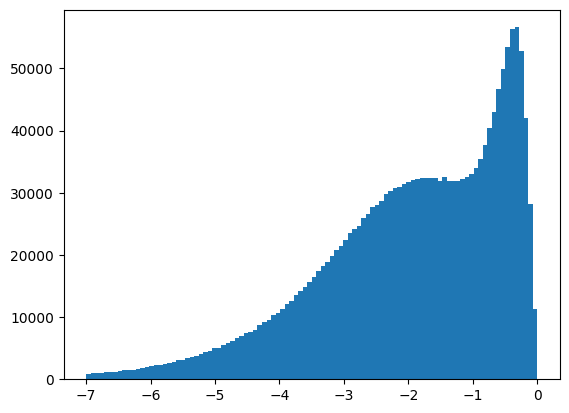

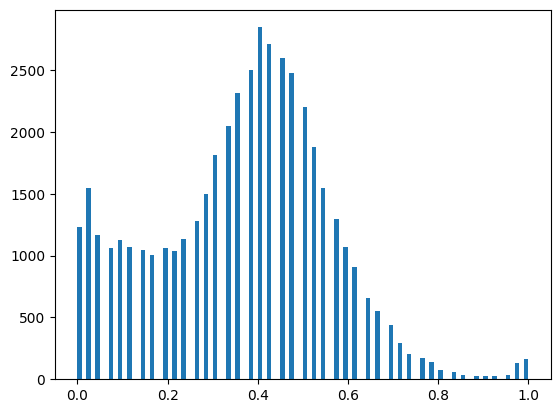

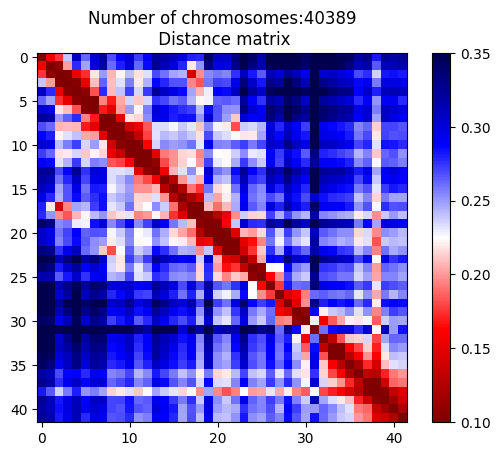

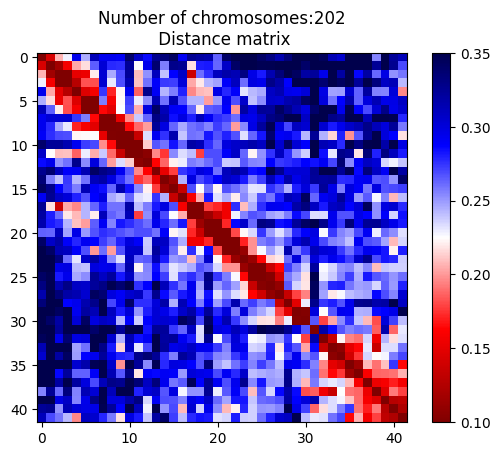

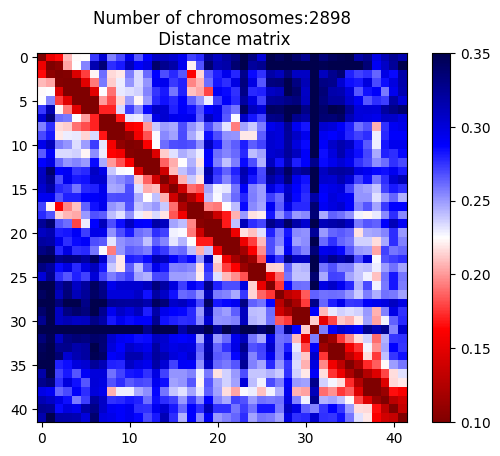

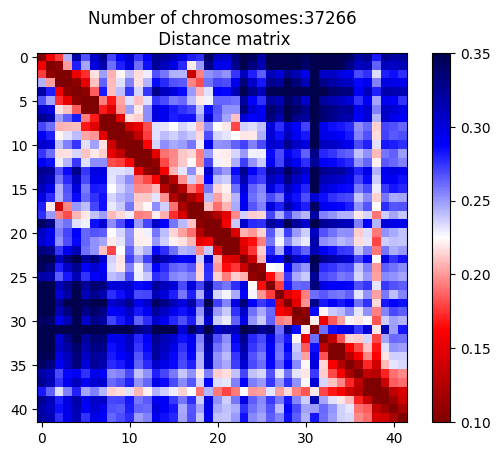

In [8]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D108_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-4]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
th6, th7 = dic['th67']
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.25]=np.nan
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D120 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
# th7,th6 =10.5, 11
keep7 = (H7>th7)&(H6<th6)
keep6 = (H6>th6)&(H7<th7)
keepN = (H6<th6)&(H7<th7)

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep7]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keep7],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()


plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep6]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keep6],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keepN]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D120[keepN],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

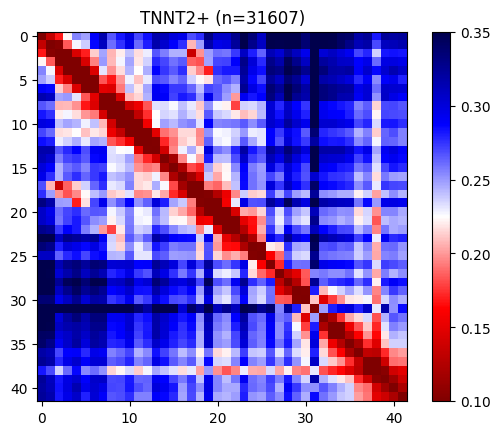

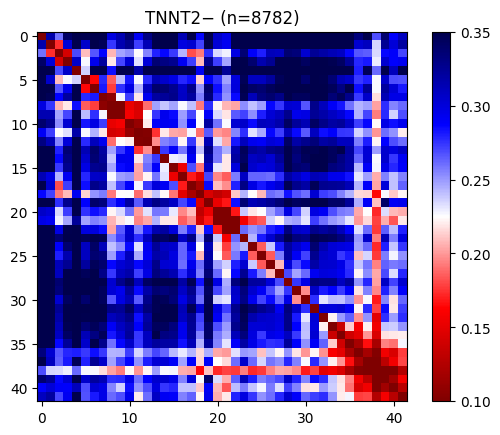

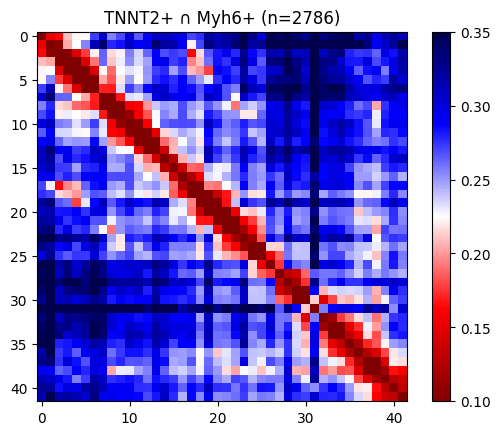

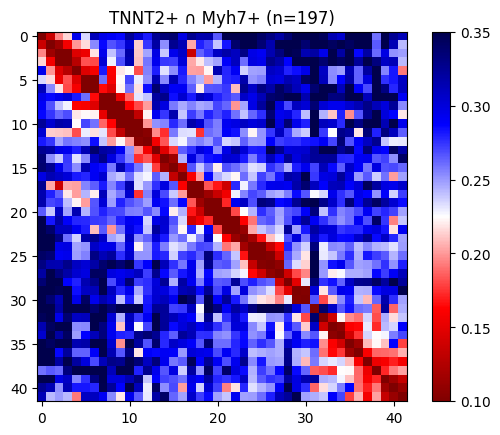

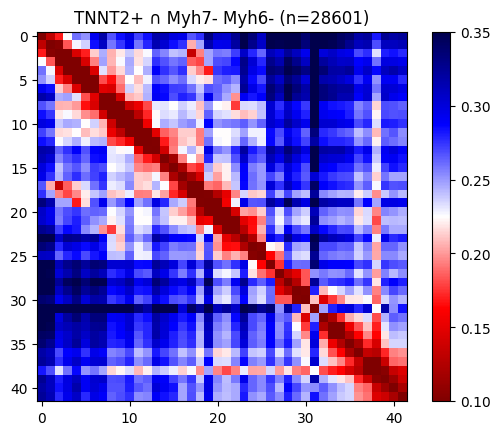

In [9]:
# Step 1: Get MYL2+ mask (assuming flag stored at last position)
is_MYL2 = zxys_fs[keep, 0, -1] == 1
is_not_MYL2 = zxys_fs[keep, 0, -1] == 0

# Step 2: Use already-defined H6, H7 and keep masks
# H6, H7 already defined as log intensities
is_H6_pos = H6 > th6
is_H7_pos = H7 > th7

# Step 3: Define combinations
keep_myl2 = is_MYL2
keep_nonmyl2 = is_not_MYL2
keep_myl2_myh6 = is_MYL2 & is_H6_pos & ~is_H7_pos
keep_myl2_myh7 = is_MYL2 & is_H7_pos & ~is_H6_pos
keep_myl2_no67 = is_MYL2 & ~is_H7_pos & ~is_H6_pos

# Step 4: Compute matrices
mats_D120_myl2     = mats_D120[keep_myl2]
mats_D120_nonmyl2  = mats_D120[keep_nonmyl2]
mats_D120_myl2_h6  = mats_D120[keep_myl2_myh6]
mats_D120_myl2_h7  = mats_D120[keep_myl2_myh7]
mats_D120_myl2_no67 = mats_D120[keep_myl2_no67]

# Step 5: Plot
plt.figure()
plt.title(f"TNNT2+ (n={len(mats_D120_myl2)})")
plt.imshow(np.nanmedian(mats_D120_myl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"TNNT2− (n={len(mats_D120_nonmyl2)})")
plt.imshow(np.nanmedian(mats_D120_nonmyl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"TNNT2+ ∩ Myh6+ (n={len(mats_D120_myl2_h6)})")
plt.imshow(np.nanmedian(mats_D120_myl2_h6, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"TNNT2+ ∩ Myh7+ (n={len(mats_D120_myl2_h7)})")
plt.imshow(np.nanmedian(mats_D120_myl2_h7, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"TNNT2+ ∩ Myh7- Myh6- (n={len(mats_D120_myl2_no67)})")
plt.imshow(np.nanmedian(mats_D120_myl2_no67, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

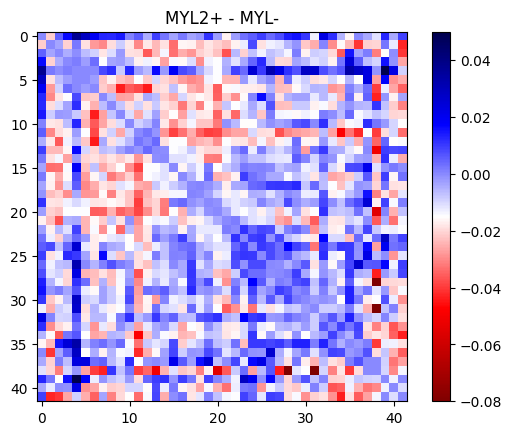

In [10]:
plt.figure()
plt.title(f"MYL2+ - MYL-")
plt.imshow(np.nanmedian(mats_D120_myl2_no67, axis=0)-np.nanmedian(mats_D120_myl2_h6, axis=0), cmap='seismic_r', vmin=-0.08, vmax=0.05)
plt.colorbar()

C:\Users\carlos\AppData\Local\Temp\ipykernel_20868\1873751004.py:26: RuntimeWarning: divide by zero encountered in log
  H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
C:\Users\carlos\anaconda3\envs\cellpose2\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


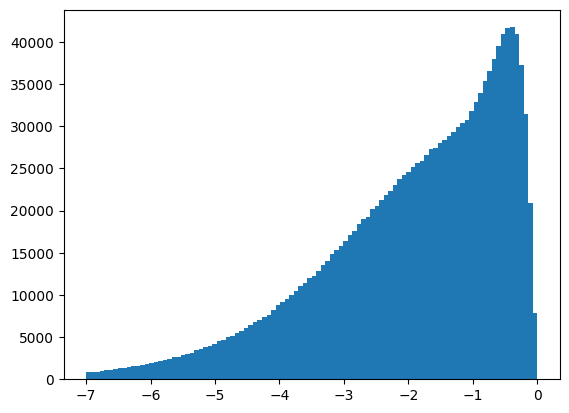

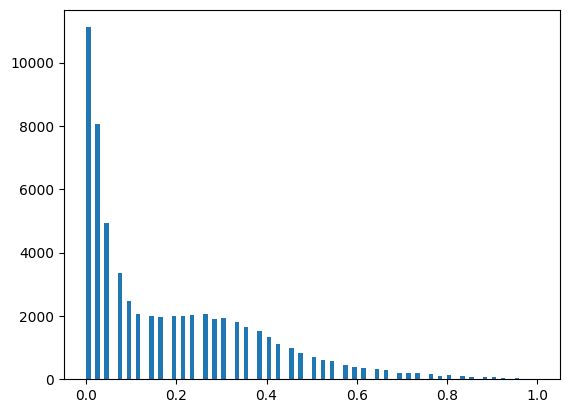

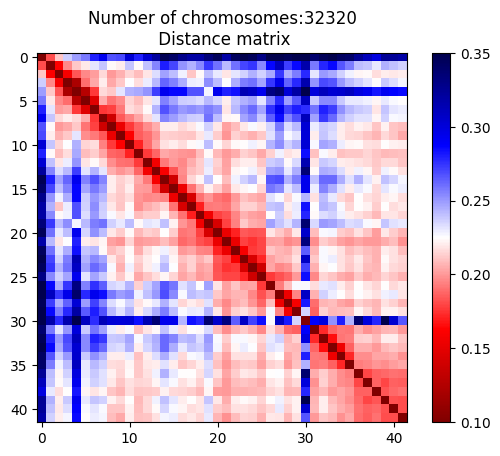

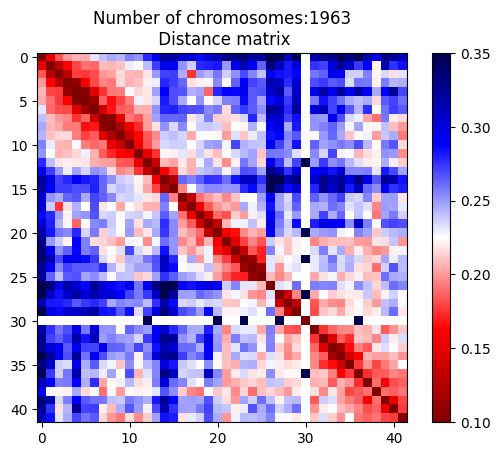

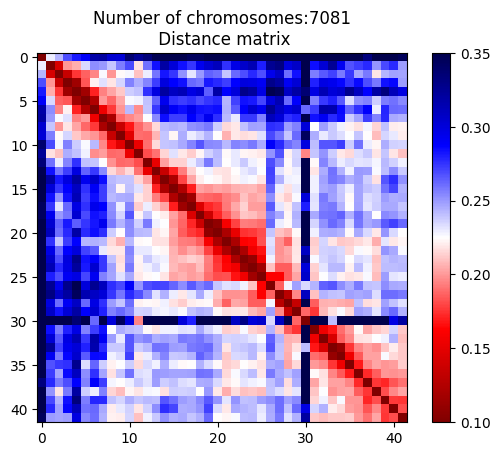

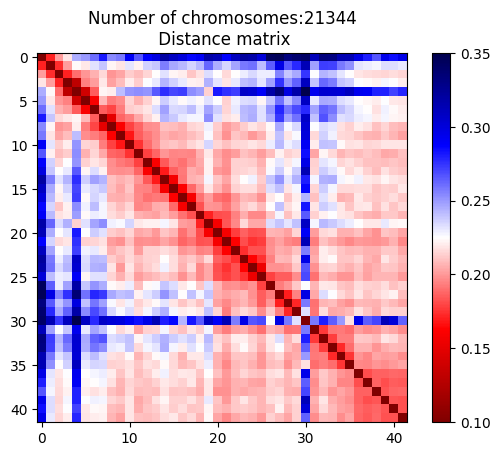

In [11]:
dic = np.load(r"C:\Users\Carlos\Desktop\Myh67_scripts\D110_traces_info.npz")#,zxys_fs=zxys_fs,score=score,icells_CMS=icells_CMS,th67=[th6,th7])
zxys_fs = dic['zxys_fs']
score = dic['score']
#icells_CMS = dic['icells_CMS']
icells = zxys_fs[:,0,-4]
score_ = score[~np.isnan(score)]
score_=score_[score_>-7]
th6, th7 = dic['th67']
plt.figure()
plt.hist(score_,bins=100);

X = zxys_fs[:,:,:3].copy()
X[score<-1.]=np.nan
fr = np.mean(~np.isnan(X[:,:,0]),axis=-1)
plt.figure()
plt.hist(fr,bins=100);
keep = (fr>0.1)#&np.in1d(icells,icells_CMS)
from scipy.spatial.distance import pdist,squareform
mats = np.array([squareform(pdist(X_)) for X_ in X[keep]])
mats_D104 = mats
plt.figure()
plt.title("Number of chromosomes:"+str(len(mats))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats,axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

H7,H6 = np.log(zxys_fs[keep,0,-2]),np.log(zxys_fs[keep,0,-3])
# th7,th6 =10.5, 11
keep7 = (H7>th7)&(H6<th6)
keep6 = (H6>th6)&(H7<th7)
keepN = (H6<th6)&(H7<th7)

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep7]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keep7],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()


plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keep6]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keep6],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

plt.figure()
plt.title("Number of chromosomes:"+str(len(mats[keepN]))+'\n Distance matrix')
plt.imshow(np.nanmedian(mats_D104[keepN],axis=0),cmap='seismic_r',vmin=0.1,vmax=0.35)
plt.colorbar()

In [46]:
mats.shape

(32320, 42, 42)

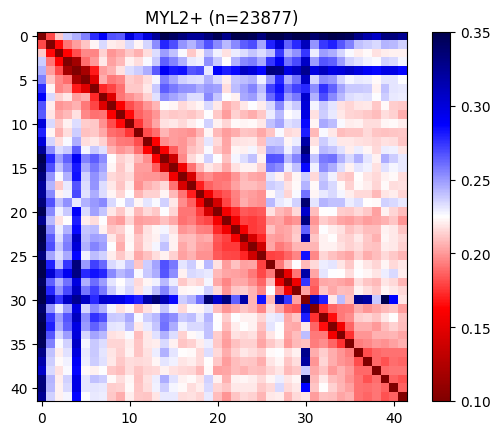

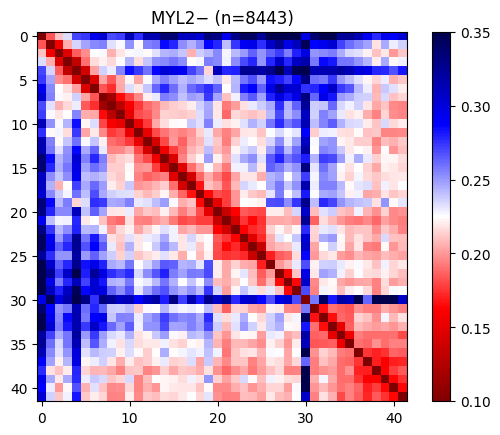

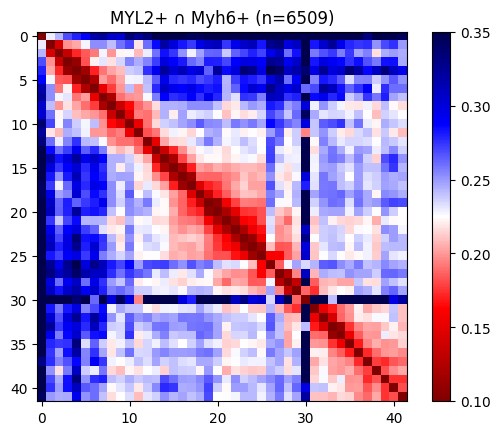

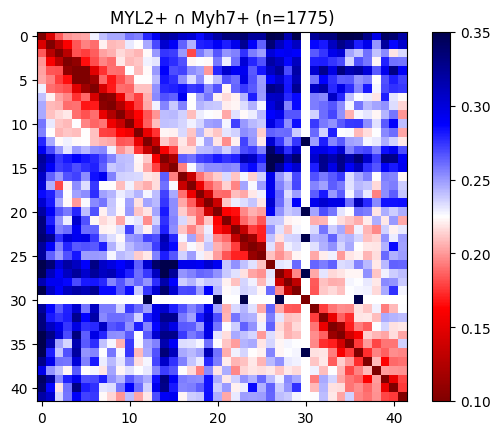

In [12]:
# Step 1: Get MYL2+ mask (assuming flag stored at last position)
is_MYL2 = zxys_fs[keep, 0, -1] == 1
is_not_MYL2 = zxys_fs[keep, 0, -1] == 0

# Step 2: Use already-defined H6, H7 and keep masks
# H6, H7 already defined as log intensities
is_H6_pos = H6 > th6
is_H7_pos = H7 > th7

# Step 3: Define combinations
keep_myl2 = is_MYL2
keep_nonmyl2 = is_not_MYL2
keep_myl2_myh6 = is_MYL2 & is_H6_pos & ~is_H7_pos
keep_myl2_myh7 = is_MYL2 & is_H7_pos & ~is_H6_pos

# Step 4: Compute matrices
mats_D104_myl2     = mats_D104[keep_myl2]
mats_D104_nonmyl2  = mats_D104[keep_nonmyl2]
mats_D104_myl2_h6  = mats_D104[keep_myl2_myh6]
mats_D104_myl2_h7  = mats_D104[keep_myl2_myh7]

# Step 5: Plot
plt.figure()
plt.title(f"MYL2+ (n={len(mats_D104_myl2)})")
plt.imshow(np.nanmedian(mats_D104_myl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2− (n={len(mats_D104_nonmyl2)})")
plt.imshow(np.nanmedian(mats_D104_nonmyl2, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh6+ (n={len(mats_D104_myl2_h6)})")
plt.imshow(np.nanmedian(mats_D104_myl2_h6, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

plt.figure()
plt.title(f"MYL2+ ∩ Myh7+ (n={len(mats_D104_myl2_h7)})")
plt.imshow(np.nanmedian(mats_D104_myl2_h7, axis=0), cmap='seismic_r', vmin=0.1, vmax=0.35)
plt.colorbar()

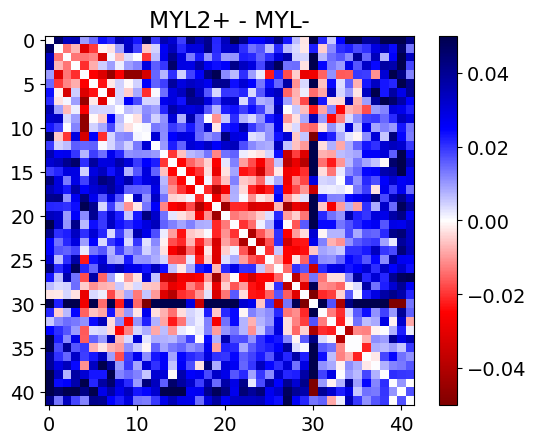

In [30]:
plt.figure()
plt.title(f"MYL2+ - MYL-")
plt.imshow(np.nanmedian(mats_D104_myl2_h6, axis=0)-np.nanmedian(mats_D104_nonmyl2, axis=0), cmap='seismic_r', vmin=-0.05, vmax=0.05)
plt.colorbar()

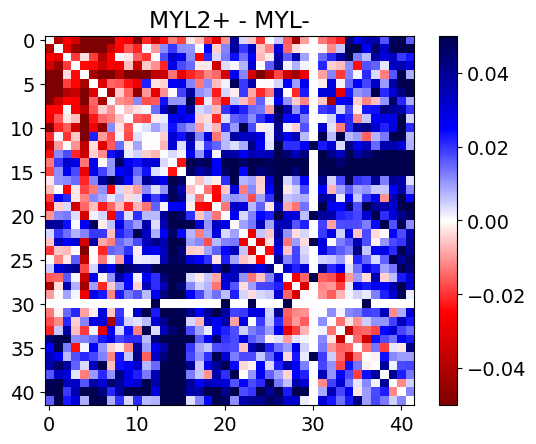

In [31]:
plt.figure()
plt.title(f"MYL2+ - MYL-")
plt.imshow(np.nanmedian(mats_D104_myl2_h7, axis=0)-np.nanmedian(mats_D104_nonmyl2, axis=0), cmap='seismic_r', vmin=-0.05, vmax=0.05)
plt.colorbar()

In [13]:

med_D104 = np.nanmedian(mats_D104,axis=0)
med_D118 = np.nanmedian(mats_D118,axis=0)
med_D104_keep7 = np.nanmedian(mats_D104[keep7],axis=0)
med_D104_keep6 = np.nanmedian(mats_D104[keep6],axis=0)
med_D104_keepN = np.nanmedian(mats_D104[keepN],axis=0)

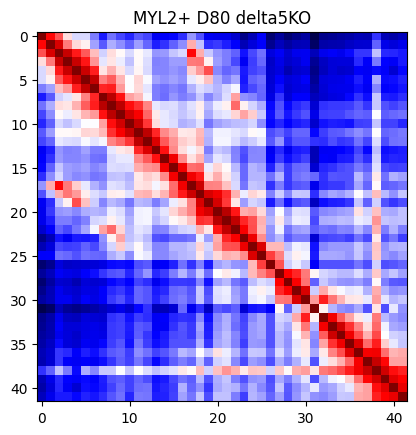

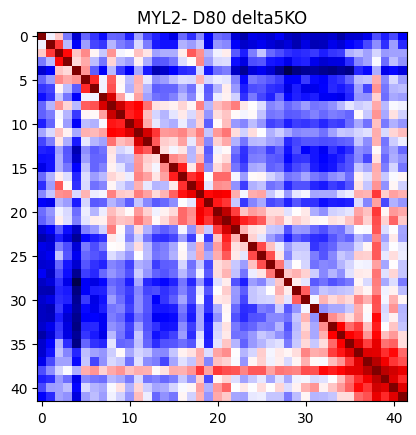

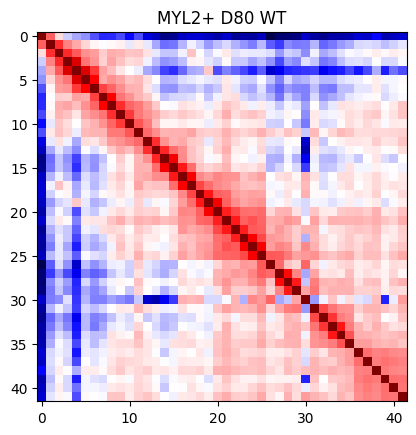

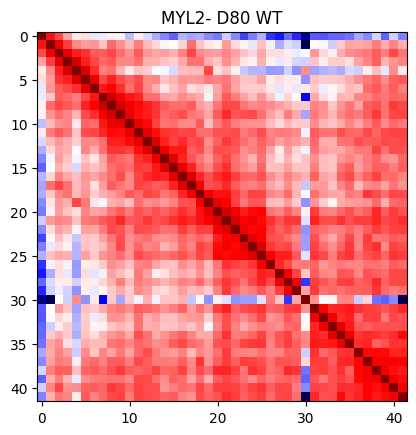

In [14]:
dth = 0.15

plt.figure()
plt.title(f"MYL2+ D80 delta5KO")
mat_delta_myl2 = np.sum(mats_D120_myl2[:]<dth,axis=0)/np.sum(mats_D120_myl2[:]>=0,axis=0)
plt.imshow(np.log(mat_delta_myl2),cmap='seismic')

plt.figure()
plt.title(f"MYL2- D80 delta5KO")
mat_delta_nonmyl2 = np.sum(mats_D120_nonmyl2[:]<dth,axis=0)/np.sum(mats_D120_nonmyl2[:]>=0,axis=0)
plt.imshow(np.log(mat_delta_nonmyl2),cmap='seismic')

plt.figure()
plt.title(f"MYL2+ D80 WT")
mat_wt_myl2 = np.sum(mats_D104_myl2[:]<dth,axis=0)/np.sum(mats_D104_myl2[:]>=0,axis=0)
plt.imshow(np.log(mat_wt_myl2),cmap='seismic')

plt.figure()
plt.title(f"MYL2- D80 WT")
mat_wt_nonmyl2 = np.sum(mats_D104_nonmyl2[:]<dth,axis=0)/np.sum(mats_D104_nonmyl2[:]>=0,axis=0)
plt.imshow(np.log(mat_wt_nonmyl2),cmap='seismic')

C:\Users\Carlos\AppData\Local\Temp\ipykernel_4216\3242135292.py:1: RuntimeWarning: invalid value encountered in divide
  plt.imshow(np.log(mat_delta_myl2)/np.log(mat_delta_nonmyl2),cmap='seismic', vmin=1, vmax = 1.5)


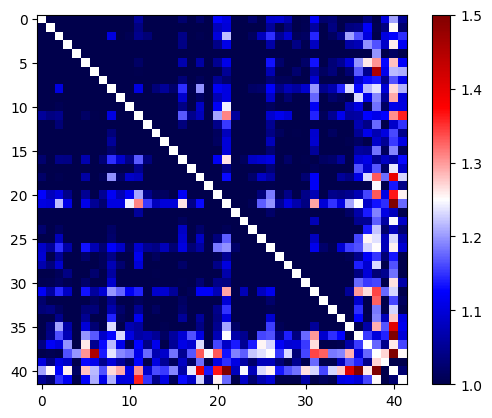

In [15]:
plt.imshow(np.log(mat_delta_myl2)/np.log(mat_delta_nonmyl2),cmap='seismic', vmin=1, vmax = 1.5)
plt.colorbar()

In [32]:
med_D120 = np.nanmedian(mats_D120,axis=0)
med_D118 = np.nanmedian(mats_D118,axis=0)
med_D104 = np.nanmedian(mats_D104, axis=0)

In [22]:
i1,i2 = [13,28]
med_D104[i1, i2], med_D120[i1, i2]

(0.23085404636396126, 0.34174916897639507)

In [23]:
i1,i2 = [13,31]
med_D104[i1, i2], med_D120[i1, i2]

(0.2237637278707314, 0.3678766055940916)

In [24]:
i1,i2 = [27,31]
med_D104[i1, i2], med_D120[i1, i2]

(0.20601099188368455, 0.2614004865333114)

In [7]:
data = [med_D120_keep.ravel()/med_D104_keep7.ravel(),med_D120_keep.ravel()/med_D104_keep6.ravel(),med_D120_keep.ravel()/med_D104_keepN.ravel(),med_D120_keep.ravel()/med_D118.ravel()]
data = [d[~np.isnan(d)]for d in data]

C:\Users\Carlos\AppData\Local\Temp\ipykernel_15760\3297490314.py:1: RuntimeWarning: invalid value encountered in divide
  data = [med_D120.ravel()/med_D104_keep7.ravel(),med_D120.ravel()/med_D104_keep6.ravel(),med_D120.ravel()/med_D104_keepN.ravel(),med_D120.ravel()/med_D118.ravel()]


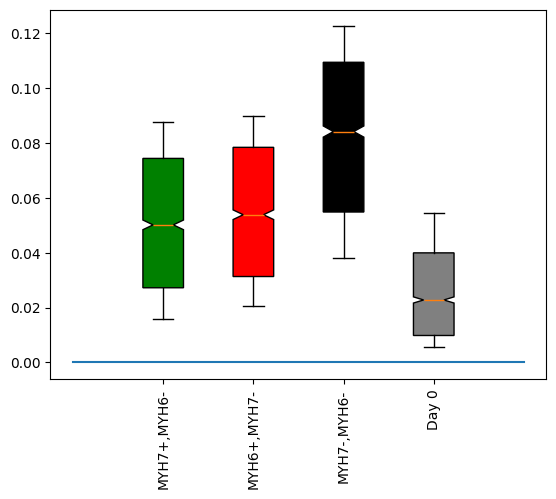

In [10]:
data = np.abs([med_D120_keep.ravel()-med_D104_keep7.ravel(),med_D120_keep.ravel()-med_D104_keep6.ravel(),med_D120_keep.ravel()-med_D104_keepN.ravel(),med_D120_keep.ravel()-med_D118.ravel()])
data = [d[~np.isnan(d)]for d in data]
bp = plt.boxplot([d for d in data], patch_artist=True, showfliers=False,whis=[15,85],notch=True,)

# Define the colors for each box
colors = ['green','red', 'black', 'gray']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.plot([0,5],[0,0])
plt.xticks(np.arange(4)+1,['MYH7+,MYH6-','MYH6+,MYH7-','MYH7-,MYH6-','Day 0'],rotation='vertical');

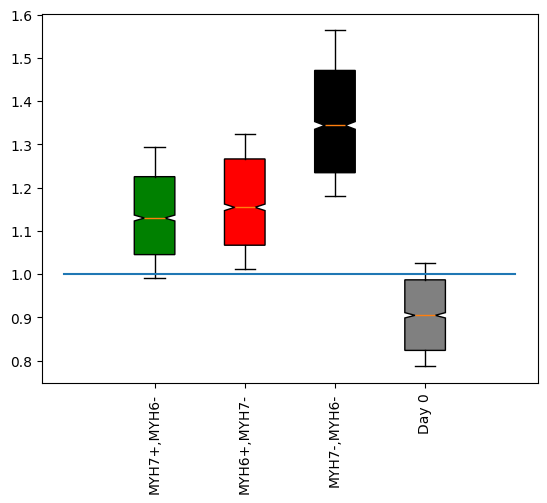

In [8]:
bp = plt.boxplot([d for d in data], patch_artist=True, showfliers=False,whis=[15,85],notch=True,)

# Define the colors for each box
colors = ['green','red', 'black', 'gray']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.plot([0,5],[1,1])
plt.xticks(np.arange(4)+1,['MYH7+,MYH6-','MYH6+,MYH7-','MYH7-,MYH6-','Day 0'],rotation='vertical');

In [13]:
# Step 4: Compute matrices
mats_D120_myl2     = mats_D120[keep_myl2]
mats_D120_nonmyl2  = mats_D120[keep_nonmyl2]
mats_D120_myl2_h6  = mats_D120[keep_myl2_myh6]
mats_D120_myl2_h7  = mats_D120[keep_myl2_myh7]

# Step 4: Compute matrices
mats_D104_myl2     = mats_D104[keep_myl2]
mats_D104_nonmyl2  = mats_D104[keep_nonmyl2]
mats_D104_myl2_h6  = mats_D104[keep_myl2_myh6]
mats_D104_myl2_h7  = mats_D104[keep_myl2_myh7]

NameError: name 'mats_D104' is not defined

In [1]:
def get_random_maps(mats,iDNA7_,N=100,dth=0.1):
    med_7_Cs = []
    for i in tqdm(np.arange(N)):
        iRand = np.random.randint(0,len(iDNA7_),len(iDNA7_))
        med_7_C = np.mean(mats[iDNA7_[iRand]]<dth,axis=0)/np.mean(mats[iDNA7_[iRand]]>=0,axis=0)
        med_7_Cs.append(med_7_C)
    return np.array(med_7_Cs)

In [15]:
from tqdm import tqdm
mats_D108_all = get_random_maps(mats_D108,np.arange(len(mats_D108)),N=100,dth=0.1)
mats_D110_all = get_random_maps(mats_D110,np.arange(len(mats_D104)),N=100,dth=0.1)
mats_D118_all = get_random_maps(mats_D118,np.arange(len(mats_D118)),N=100,dth=0.1)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:32<00:00,  3.06it/s]


NameError: name 'mats_D110' is not defined

In [56]:
from tqdm import tqdm
# mats_D103_7 = get_random_maps(mats_D103,np.where(keep7)[0],N=100,dth=0.1)
# mats_D103_6 = get_random_maps(mats_D103,np.where(keep6)[0],N=100,dth=0.1)
size = 200
mats_D120_p = get_random_maps(mats_D120_myl2,np.arange(len(mats_D120_myl2)),N=size,dth=0.15)
mats_D120_m = get_random_maps(mats_D120_nonmyl2,np.arange(len(mats_D120_nonmyl2)),N=size,dth=0.15)
mats_D104_p = get_random_maps(mats_D104_myl2,np.arange(len(mats_D104_myl2)),N=size,dth=0.15)
mats_D104_m = get_random_maps(mats_D104_nonmyl2,np.arange(len(mats_D104_nonmyl2)),N=size,dth=0.15)
mats_D118_all = get_random_maps(mats_D118,np.arange(len(mats_D118)),N=size,dth=0.15)

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [03:16<00:00,  1.02it/s]


In [25]:
from tqdm import tqdm
# mats_D103_7 = get_random_maps(mats_D103,np.where(keep7)[0],N=100,dth=0.1)
# mats_D103_6 = get_random_maps(mats_D103,np.where(keep6)[0],N=100,dth=0.1)

mats_D120_p_h6 = get_random_maps(mats_D120_myl2_h6,np.arange(len(mats_D120_myl2_h6)),N=100,dth=0.1)
mats_D120_p_h7 = get_random_maps(mats_D120_myl2_h7,np.arange(len(mats_D120_myl2_h7)),N=100,dth=0.1)
mats_D104_p_h6 = get_random_maps(mats_D104_myl2_h6,np.arange(len(mats_D104_myl2_h6)),N=100,dth=0.1)
mats_D104_p_h7 = get_random_maps(mats_D104_myl2_h7,np.arange(len(mats_D104_myl2_h7)),N=100,dth=0.1)

  0%|                                                                                          | 0/100 [00:00<?, ?it/s]C:\Users\Carlos\AppData\Local\Temp\ipykernel_14684\945849956.py:5: RuntimeWarning: invalid value encountered in divide
  med_7_C = np.mean(mats[iDNA7_[iRand]]<dth,axis=0)/np.mean(mats[iDNA7_[iRand]]>=0,axis=0)
100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 67.78it/s]


In [36]:
mats_D120_all = get_random_maps(mats_D120,np.arange(len(mats_D120)),N=100,dth=0.15)
mats_D104_all = get_random_maps(mats_D104,np.arange(len(mats_D104)),N=100,dth=0.15)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:26<00:00,  3.81it/s]


In [63]:
len(mats_D120_myl2), len(mats_D104_myl2)

(31607, 23877)

Rank-sum p-value between D15 DKO and D15 WT: 4.79e-67


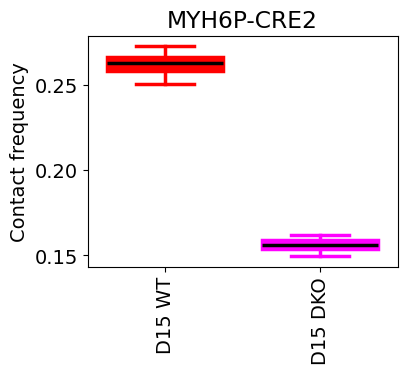

In [64]:
from scipy.stats import ranksums
import matplotlib.pyplot as plt
import numpy as np

# Define region
i1, i2 = [13, 28]
line_width = 2.5

# Extract data
X = mats_D120_p[:, i1, i2]
Z = mats_D104_p[:, i1, i2]

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 DKO and D15 WT: {pval:.2e}")

# Plotting
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4, 3))

box_X = ax.boxplot(X, positions=[0.2], patch_artist=True,
                   boxprops=dict(facecolor='magenta', color='magenta', linewidth=line_width),
                   whiskerprops=dict(color='magenta', linewidth=line_width),
                   capprops=dict(color='magenta', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

box_Z = ax.boxplot(Z, positions=[0], patch_artist=True,
                   boxprops=dict(facecolor='red', color='red', linewidth=line_width),
                   whiskerprops=dict(color='red', linewidth=line_width),
                   capprops=dict(color='red', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

# Axis formatting
plt.xlim([-0.1, 0.3])
plt.xticks([0, 0.2], ['D15 WT', 'D15 DKO'], rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

# Save figure
plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure3\Figure3_{i1}_{i2}_D15.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

Rank-sum p-value between D15 DKO and D15 WT: 4.79e-67


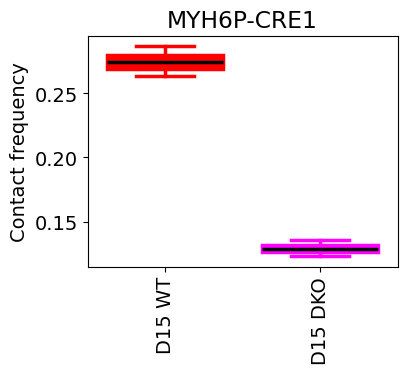

In [65]:
from scipy.stats import ranksums
import matplotlib.pyplot as plt
import numpy as np

# Define region
i1, i2 = [13, 31]
line_width = 2.5

# Extract data
X = mats_D120_p[:, i1, i2]
Z = mats_D104_p[:, i1, i2]

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 DKO and D15 WT: {pval:.2e}")

# Plotting
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4, 3))

box_X = ax.boxplot(X, positions=[0.2], patch_artist=True,
                   boxprops=dict(facecolor='magenta', color='magenta', linewidth=line_width),
                   whiskerprops=dict(color='magenta', linewidth=line_width),
                   capprops=dict(color='magenta', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

box_Z = ax.boxplot(Z, positions=[0], patch_artist=True,
                   boxprops=dict(facecolor='red', color='red', linewidth=line_width),
                   whiskerprops=dict(color='red', linewidth=line_width),
                   capprops=dict(color='red', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

# Axis formatting
plt.xlim([-0.1, 0.3])
plt.xticks([0, 0.2], ['D15 WT', 'D15 DKO'], rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

# Save figure
plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure3\Figure3_{i1}_{i2}_D15.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

Rank-sum p-value between D15 DKO and D15 WT: 1.40e-65


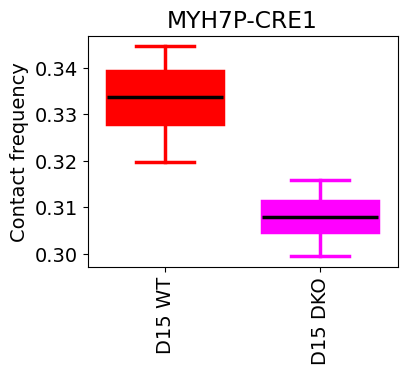

In [66]:
from scipy.stats import ranksums
import matplotlib.pyplot as plt
import numpy as np

# Define region
i1, i2 = [27, 31]
line_width = 2.5

# Extract data
X = mats_D120_p[:, i1, i2]
Z = mats_D104_p[:, i1, i2]

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 DKO and D15 WT: {pval:.2e}")

# Plotting
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4, 3))

box_X = ax.boxplot(X, positions=[0.2], patch_artist=True,
                   boxprops=dict(facecolor='magenta', color='magenta', linewidth=line_width),
                   whiskerprops=dict(color='magenta', linewidth=line_width),
                   capprops=dict(color='magenta', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

box_Z = ax.boxplot(Z, positions=[0], patch_artist=True,
                   boxprops=dict(facecolor='red', color='red', linewidth=line_width),
                   whiskerprops=dict(color='red', linewidth=line_width),
                   capprops=dict(color='red', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

# Axis formatting
plt.xlim([-0.1, 0.3])
plt.xticks([0, 0.2], ['D15 WT', 'D15 DKO'], rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

# Save figure
plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure3\Figure3_{i1}_{i2}_D15.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

In [31]:
def get_random_maps(mats,iDNA7_,N=100,dth=0.1):
    med_7_Cs = []
    for i in tqdm(np.arange(N)):
        iRand = np.random.randint(0,len(iDNA7_),len(iDNA7_))
        med_7_C = np.mean(mats[iDNA7_[iRand]]<dth,axis=0)/np.mean(mats[iDNA7_[iRand]]>=0,axis=0)
        med_7_Cs.append(med_7_C)
    return np.array(med_7_Cs)

In [32]:
mats_D120_all = get_random_maps(mats_D120,np.arange(len(mats_D120)),N=100,dth=0.1)
mats_D104_all = get_random_maps(mats_D104,np.arange(len(mats_D104)),N=100,dth=0.1)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:25<00:00,  3.89it/s]


Rank-sum p-value between D15 DKO and D15 WT: 2.60e-34


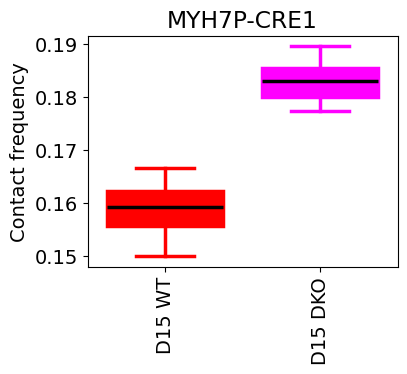

In [33]:
from scipy.stats import ranksums
import matplotlib.pyplot as plt
import numpy as np

# Define region
i1, i2 = [27, 31]
line_width = 2.5

# Extract data
X = mats_D120_all[:, i1, i2]
Z = mats_D104_all[:, i1, i2]

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 DKO and D15 WT: {pval:.2e}")

# Plotting
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4, 3))

box_X = ax.boxplot(X, positions=[0.2], patch_artist=True,
                   boxprops=dict(facecolor='magenta', color='magenta', linewidth=line_width),
                   whiskerprops=dict(color='magenta', linewidth=line_width),
                   capprops=dict(color='magenta', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

box_Z = ax.boxplot(Z, positions=[0], patch_artist=True,
                   boxprops=dict(facecolor='red', color='red', linewidth=line_width),
                   whiskerprops=dict(color='red', linewidth=line_width),
                   capprops=dict(color='red', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

# Axis formatting
plt.xlim([-0.1, 0.3])
plt.xticks([0, 0.2], ['D15 WT', 'D15 DKO'], rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

# Save figure
plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure3\Figure3_{i1}_{i2}_D15.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

Rank-sum p-value between D15 DKO and D15 WT: 2.52e-34


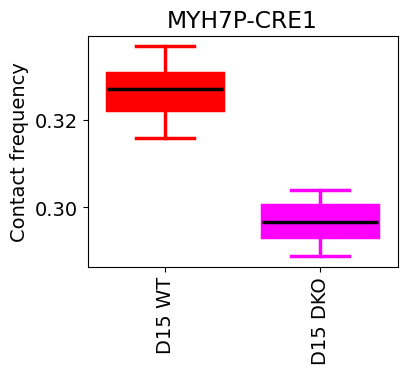

In [35]:
from scipy.stats import ranksums
import matplotlib.pyplot as plt
import numpy as np

# Define region
i1, i2 = [27, 31]
line_width = 2.5

# Extract data
X = mats_D120_all_1[:, i1, i2]
Z = mats_D104_all_1[:, i1, i2]

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 DKO and D15 WT: {pval:.2e}")

# Plotting
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4, 3))

box_X = ax.boxplot(X, positions=[0.2], patch_artist=True,
                   boxprops=dict(facecolor='magenta', color='magenta', linewidth=line_width),
                   whiskerprops=dict(color='magenta', linewidth=line_width),
                   capprops=dict(color='magenta', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

box_Z = ax.boxplot(Z, positions=[0], patch_artist=True,
                   boxprops=dict(facecolor='red', color='red', linewidth=line_width),
                   whiskerprops=dict(color='red', linewidth=line_width),
                   capprops=dict(color='red', linewidth=line_width),
                   medianprops=dict(color='k', linewidth=line_width), whis=[5, 95], showfliers=False)

# Axis formatting
plt.xlim([-0.1, 0.3])
plt.xticks([0, 0.2], ['D15 WT', 'D15 DKO'], rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

# Save figure
plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure3\Figure3_{i1}_{i2}_D15.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

In [28]:
import numpy as np
from tqdm import tqdm

def get_random_med(mats, iDNA7_, N=100):
    med_7_Cs = []
    for i in tqdm(np.arange(N)):
        # sample with replacement
        iRand = np.random.randint(0, len(iDNA7_), len(iDNA7_))
        # take subset and compute nanmedian along axis=0
        med_7_C = np.nanmedian(mats[iDNA7_[iRand]], axis=0)
        med_7_Cs.append(med_7_C)
    return np.array(med_7_Cs)

In [29]:
mats_D120_med = get_random_med(mats_D120,np.arange(len(mats_D120)),N=100)
mats_D104_med = get_random_med(mats_D104,np.arange(len(mats_D104)),N=100)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:54<00:00,  1.83it/s]


Rank-sum p-value between D15 DKO and D15 WT: 2.52e-34


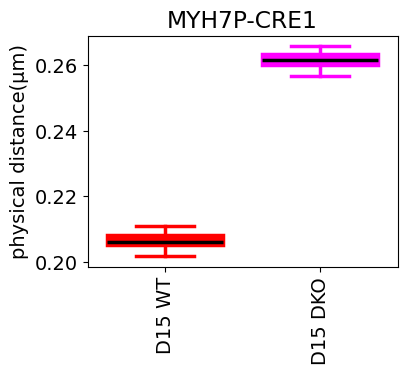

In [30]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_med[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_med[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 DKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D15 WT','D15 DKO'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("physical distance(µm)")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure3DKO_{i1}_{i2}_dis.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D15 DKO and D15 WT: 2.52e-34


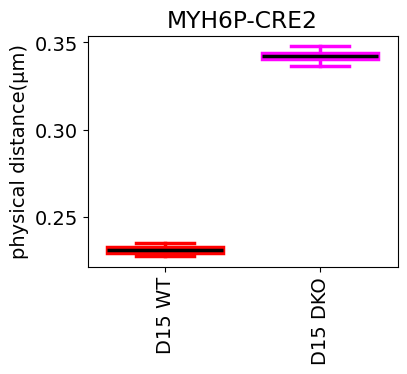

In [22]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_med[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_med[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 DKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D15 WT','D15 DKO'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("physical distance(µm)")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure3DKO_{i1}_{i2}_dis.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D15 DKO and D15 WT: 2.52e-34


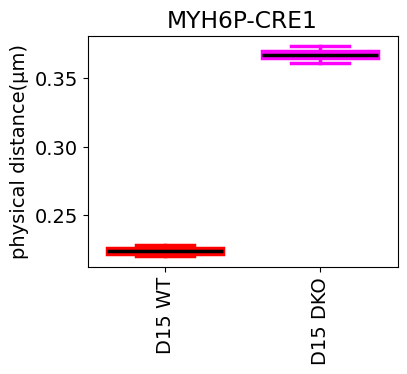

In [23]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_med[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_med[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 DKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D15 WT','D15 DKO'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("physical distance(µm)")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure3DKO_{i1}_{i2}_dis.pdf", format='pdf', bbox_inches='tight', dpi=600)

Rank-sum p-value between D15 DKO and D15 WT: 2.52e-34


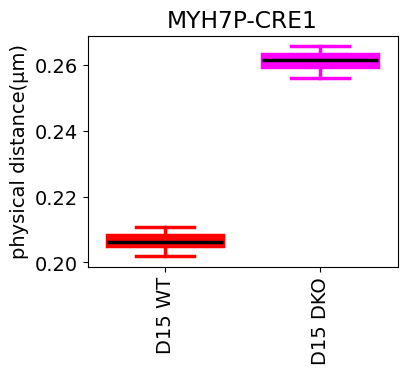

In [24]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_med[:,i1,i2]
box_X = ax.boxplot(X, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_med[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# Rank-sum test
stat, pval = ranksums(X, Z)
print(f"Rank-sum p-value between D15 DKO and D15 WT: {pval:.2e}")

plt.xlim([-0.1,0.3])
plt.xticks([0,0.2],['D15 WT','D15 DKO'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("physical distance(µm)")

plt.savefig(fr"C:\Users\Carlos\Desktop\Myh67_scripts\Figures\Figure3DKO_{i1}_{i2}_dis.pdf", format='pdf', bbox_inches='tight', dpi=600)

In [58]:
X

array([0.07139964, 0.07634494, 0.07524713, 0.07606085, 0.07964602,
       0.07769929, 0.07632677, 0.07756708, 0.07026867, 0.07845864,
       0.07399556, 0.07493025, 0.07705672, 0.07349422, 0.07249596,
       0.07536728, 0.07633889, 0.07207386, 0.07306073, 0.07738642,
       0.07355464, 0.08102431, 0.07217822, 0.0774577 , 0.07405122,
       0.07571199, 0.08094127, 0.07432024, 0.07137759, 0.07689973,
       0.07428745, 0.06869301, 0.08088762, 0.07657977, 0.07847285,
       0.07731803, 0.07600901, 0.07193455, 0.07621951, 0.07778001,
       0.07670029, 0.07185629, 0.07336024, 0.0734    , 0.0771608 ,
       0.073332  , 0.07336332, 0.07468797, 0.08048048, 0.07417219,
       0.07676204, 0.08174524, 0.07870094, 0.07867917, 0.07681578,
       0.07880945, 0.08100132, 0.07430743, 0.07571486, 0.07374721,
       0.07771712, 0.07728175, 0.07555511, 0.07778003, 0.0766526 ,
       0.07395242, 0.07541115, 0.07524224, 0.07414506, 0.07353089,
       0.07892896, 0.07571514, 0.07582657, 0.07516439, 0.07656

In [57]:
print("X length:", len(X))
print("Z length:", len(Z))

print("X unique:", np.unique(X).size)
print("Z unique:", np.unique(Z).size)

# Check if they are exactly the same as previous experiment
#print("X equal to previous X:", np.allclose(X, X_prev))
#print("Z equal to previous Z:", np.allclose(Z, Z_prev))

# Check effect size
print("Median X:", np.median(X), "Median Z:", np.median(Z))
print("Mean X:", np.mean(X), "Mean Z:", np.mean(Z))

# Check rank sums explicitly
combined = np.concatenate([X, Z])
ranks = np.argsort(np.argsort(combined))
labels = np.array([1]*len(X) + [0]*len(Z))

rank_sum_X = ranks[:len(X)].sum()
rank_sum_Z = ranks[len(X):].sum()

print("Rank sum X:", rank_sum_X)
print("Rank sum Z:", rank_sum_Z)

X length: 100
Z length: 100
X unique: 100
Z unique: 100
Median X: 0.07614018043703255 Median Z: 0.11343090515803407
Mean X: 0.07598949917643559 Mean Z: 0.11348528463425653
Rank sum X: 4950
Rank sum Z: 14950


Text(0, 0.5, 'Contact frequency')

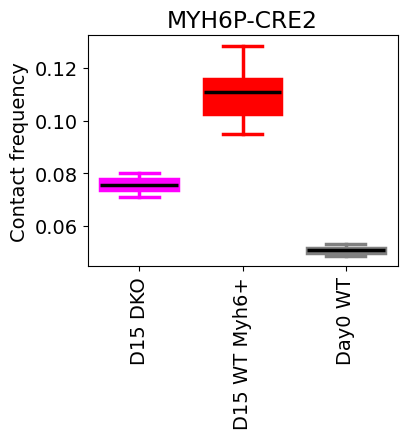

In [51]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_all[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p_h6[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D15 DKO','D15 WT Myh6+','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

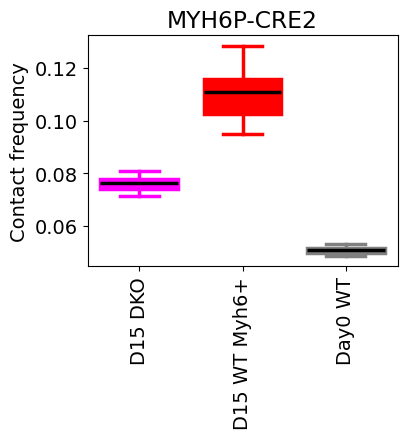

In [52]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p_h6[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D15 DKO','D15 WT Myh6+','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

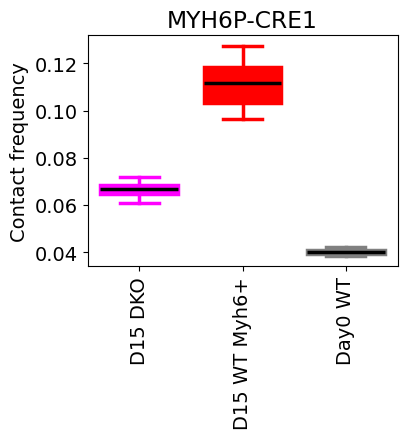

In [46]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p_h6[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D15 DKO','D15 WT Myh6+','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

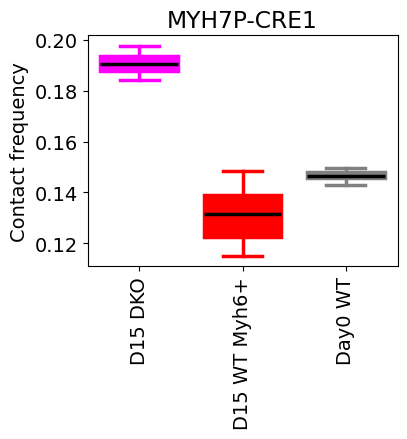

In [47]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p_h6[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D15 DKO','D15 WT Myh6+','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_11936\3150344836.py:17: RuntimeWarning: divide by zero encountered in divide
  Z = (mats_D104_p/mats_D104_m)[:,i1,i2]


Text(0, 0.5, 'Contact frequency')

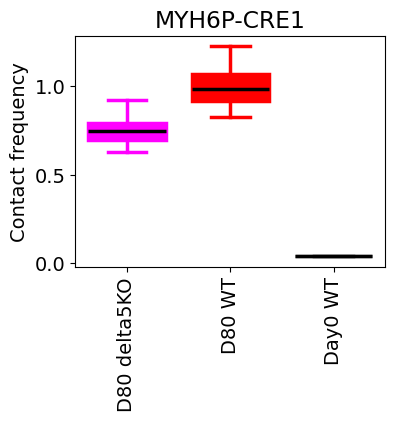

In [70]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = (mats_D120_p/mats_D120_m)[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = (mats_D104_p/mats_D104_m)[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_11936\130861578.py:17: RuntimeWarning: divide by zero encountered in divide
  Z = (mats_D104_p/mats_D104_m)[:,i1,i2]


Text(0, 0.5, 'Contact frequency')

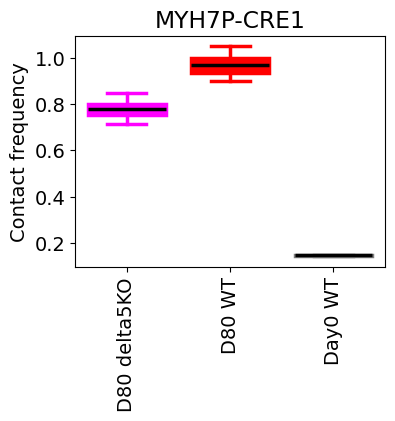

In [72]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = (mats_D120_p/mats_D120_m)[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = (mats_D104_p/mats_D104_m)[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

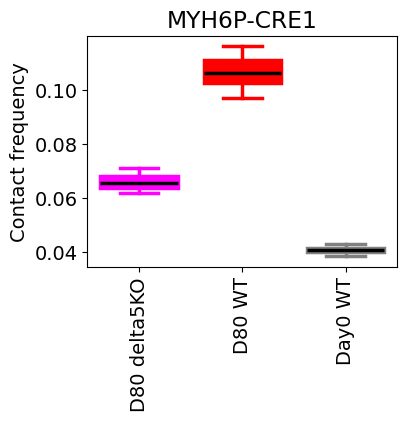

In [18]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

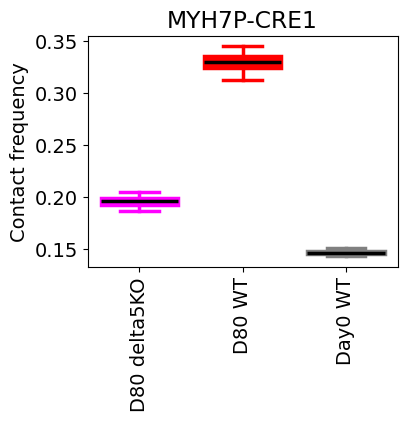

In [19]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))
# X = mats_D103_6[:,i1,i2]
# box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
#                    boxprops=dict(facecolor='red', color='red',linewidth=line_width),
#                    whiskerprops=dict(color='red',linewidth=line_width),
#                    capprops=dict(color='red',linewidth=line_width),
#                    medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

# # Box plot for Y in green
# Y = mats_D103_7[:,i1,i2]
# box_Y = ax.boxplot(Y, positions=[0.2], patch_artist=True, 
#                    boxprops=dict(facecolor='green', color='green',linewidth=line_width),
#                    whiskerprops=dict(color='green',linewidth=line_width),
#                    capprops=dict(color='green',linewidth=line_width),
#                    medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

X = mats_D120_p[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_p[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

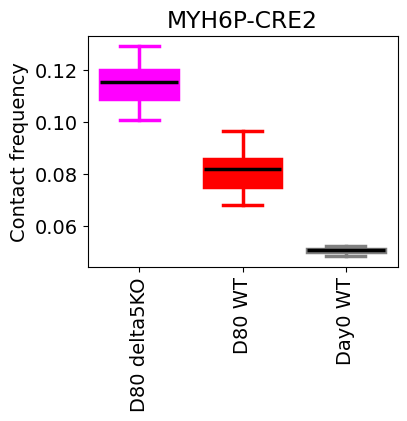

In [20]:
i1,i2 = [13,28]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE2')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

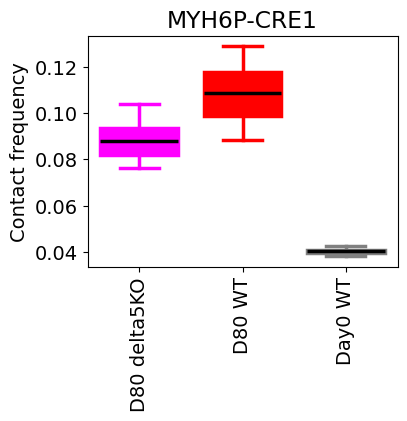

In [21]:
i1,i2 = [13,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH6P-CRE1')
plt.ylabel("Contact frequency")

Text(0, 0.5, 'Contact frequency')

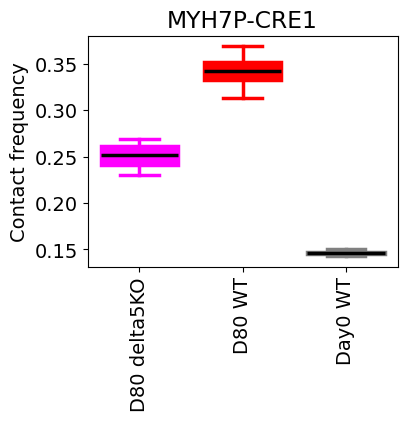

In [22]:
i1,i2 = [27,31]
line_width = 2.5
import matplotlib.pyplot as plt
import numpy as np

# Set global font size
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4,3))

X = mats_D120_m[:,i1,i2]
box_X = ax.boxplot(X, positions=[0], patch_artist=True, 
                   boxprops=dict(facecolor='magenta', color='magenta',linewidth=line_width),
                   whiskerprops=dict(color='magenta',linewidth=line_width),
                   capprops=dict(color='magenta',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

Z = mats_D104_m[:,i1,i2]
box_Y = ax.boxplot(Z, positions=[0.2], patch_artist=True, 
                   boxprops=dict(facecolor='red', color='red',linewidth=line_width),
                   whiskerprops=dict(color='red',linewidth=line_width),
                   capprops=dict(color='red',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)

W = mats_D118_all[:,i1,i2]
box_Y = ax.boxplot(W, positions=[0.4], patch_artist=True, 
                   boxprops=dict(facecolor='gray', color='gray',linewidth=line_width),
                   whiskerprops=dict(color='gray',linewidth=line_width),
                   capprops=dict(color='gray',linewidth=line_width),
                   medianprops=dict(color='k',linewidth=line_width),whis=[5,95],showfliers=False)
plt.xlim([-0.1,0.5])
plt.xticks([0,0.2,0.4],['D80 delta5KO','D80 WT','Day0 WT'],rotation='vertical')
plt.title('MYH7P-CRE1')
plt.ylabel("Contact frequency")